In [1]:
#setup
from google.colab import drive
drive.mount('/content/drive')

import sys
from pathlib import Path

PROJECT_DIR = Path('/content/drive/MyDrive/Proyek_CRM_KELOMPOK')
sys.path.append(str(PROJECT_DIR))

from project_config import CLEAN_DATA_PATH, PROCESSED_DIR, OUTPUT_DIR

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

Mounted at /content/drive


In [2]:
# Load data dan model
df_clean = pd.read_csv(CLEAN_DATA_PATH)
modeling_df = pd.read_csv(PROCESSED_DIR / 'modeling_dataset.csv')

model = joblib.load(OUTPUT_DIR / 'best_random_forest_model.joblib')

print(df_clean.shape)
print(modeling_df.shape)

(286, 56)
(286, 54)


In [3]:
# Feature importance
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
importances = model.named_steps['model'].feature_importances_

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

feature_importance['feature_clean'] = (
    feature_importance['feature']
    .str.replace('num__', '', regex=False)
    .str.replace('cat__', '', regex=False)
)

feature_importance.head(20)

,feature,importance,feature_clean
52,cat__Time saving_Disagree,0.065863,Time saving_Disagree
47,cat__Ease and convenient_Disagree,0.065844,Ease and convenient_Disagree
57,cat__More restaurant choices_Disagree,0.052691,More restaurant choices_Disagree
81,cat__Self Cooking_Agree,0.034735,Self Cooking_Agree
62,cat__Easy Payment option_Disagree,0.031430,Easy Payment option_Disagree
0,num__Age,0.031312,Age
152,cat__Maximum wait time_15 minutes,0.027961,Maximum wait time_15 minutes
46,cat__Ease and convenient_Agree,0.026907,Ease and convenient_Agree
67,cat__More Offers and Discount_Disagree,0.026190,More Offers and Discount_Disagree
2,num__latitude,0.019133,latitude


In [4]:
# Simpan feature importance
feature_importance_path = OUTPUT_DIR / 'feature_importance_result.csv'
feature_importance.to_csv(feature_importance_path, index=False)

print('Feature importance disimpan:', feature_importance_path)

Feature importance disimpan: /content/drive/MyDrive/Proyek_CRM_KELOMPOK/outputs/feature_importance_result.csv


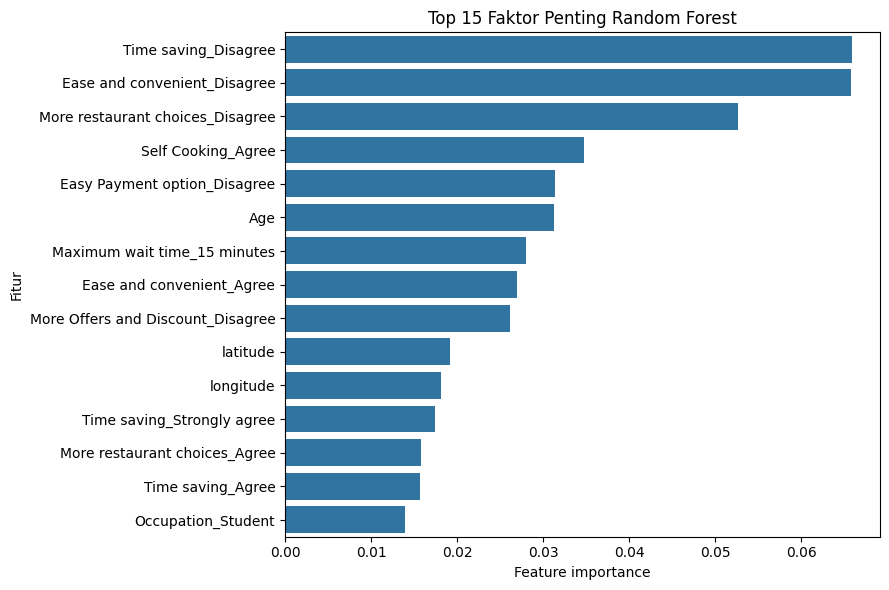

In [5]:
# grafik fitur
top_features = feature_importance.head(15)

plt.figure(figsize=(9, 6))
sns.barplot(data=top_features, x='importance', y='feature_clean')

plt.title('Top 15 Faktor Penting Random Forest')
plt.xlabel('Feature importance')
plt.ylabel('Fitur')

plt.tight_layout()

chart_path = OUTPUT_DIR / '07_feature_importance_random_forest.png'
plt.savefig(chart_path, dpi=300, bbox_inches='tight')
plt.show()

In [6]:
# Hitung risk score semua pelanggan
X_all = modeling_df.drop(columns=['churn_risk'])

df_risk = df_clean.copy()
df_risk['risk_score'] = model.predict_proba(X_all)[:, 1]

df_risk[['Output', 'churn_risk', 'risk_score']].head()

,Output,churn_risk,risk_score
0,Yes,0,0.108866
1,Yes,0,0.198212
2,Yes,0,0.140957
3,Yes,0,0.163475
4,Yes,0,0.134960


In [7]:
# Buat risk segment
def assign_risk_segment(score):
    if score >= 0.70:
        return 'High Risk'
    elif score >= 0.40:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df_risk['risk_segment'] = df_risk['risk_score'].apply(assign_risk_segment)

df_risk['risk_segment'].value_counts()

,count
risk_segment,
Low Risk,213
High Risk,40
Medium Risk,33


In [9]:
# Simpan customer risk scoring
risk_path = PROCESSED_DIR / 'customer_risk_scoring.csv'
df_risk.to_csv(risk_path, index=False)

print('Customer risk scoring disimpan:', risk_path)

Customer risk scoring disimpan: /content/drive/MyDrive/Proyek_CRM_KELOMPOK/data/processed/customer_risk_scoring.csv


In [10]:
# Ringkasan segmen
risk_segment_summary = (
    df_risk.groupby('risk_segment')
    .agg(
        total_customer=('risk_segment', 'count'),
        avg_risk_score=('risk_score', 'mean'),
        actual_churn_risk=('churn_risk', 'mean')
    )
    .reset_index()
)

risk_segment_summary['actual_churn_risk'] = risk_segment_summary['actual_churn_risk'] * 100
risk_segment_summary


,risk_segment,total_customer,avg_risk_score,actual_churn_risk
0,High Risk,40,0.807369,95.000000
1,Low Risk,213,0.203294,1.877934
2,Medium Risk,33,0.542101,69.696970


In [11]:
# Simpan ringkasan segmen
segment_summary_path = OUTPUT_DIR / 'risk_segment_summary.csv'
risk_segment_summary.to_csv(segment_summary_path, index=False)

print('Risk segment summary disimpan:', segment_summary_path)

Risk segment summary disimpan: /content/drive/MyDrive/Proyek_CRM_KELOMPOK/outputs/risk_segment_summary.csv


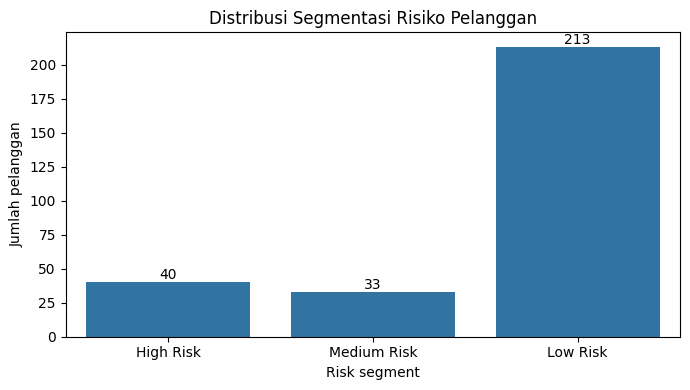

In [12]:
#Grafik risk segment
plt.figure(figsize=(7, 4))
ax = sns.countplot(
    data=df_risk,
    x='risk_segment',
    order=['High Risk', 'Medium Risk', 'Low Risk']
)

plt.title('Distribusi Segmentasi Risiko Pelanggan')
plt.xlabel('Risk segment')
plt.ylabel('Jumlah pelanggan')

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

chart_path = OUTPUT_DIR / '08_risk_segment_distribution.png'
plt.savefig(chart_path, dpi=300, bbox_inches='tight')
plt.show()